Epoch 100/5000, Loss: 0.477985
Epoch 200/5000, Loss: 0.454335
Epoch 300/5000, Loss: 0.441789
Epoch 400/5000, Loss: 0.426099
Epoch 500/5000, Loss: 0.406252
Epoch 600/5000, Loss: 0.382797
Epoch 700/5000, Loss: 0.355590
Epoch 800/5000, Loss: 0.326337
Epoch 900/5000, Loss: 0.297656
Epoch 1000/5000, Loss: 0.271351
Epoch 1100/5000, Loss: 0.248250
Epoch 1200/5000, Loss: 0.228590
Epoch 1300/5000, Loss: 0.212286
Epoch 1400/5000, Loss: 0.199037
Epoch 1500/5000, Loss: 0.188372
Epoch 1600/5000, Loss: 0.179745
Epoch 1700/5000, Loss: 0.172684
Epoch 1800/5000, Loss: 0.166848
Epoch 1900/5000, Loss: 0.161956
Epoch 2000/5000, Loss: 0.157744
Epoch 2100/5000, Loss: 0.153987
Epoch 2200/5000, Loss: 0.150521
Epoch 2300/5000, Loss: 0.147225
Epoch 2400/5000, Loss: 0.144012
Epoch 2500/5000, Loss: 0.140791
Epoch 2600/5000, Loss: 0.137419
Epoch 2700/5000, Loss: 0.133774
Epoch 2800/5000, Loss: 0.129959
Epoch 2900/5000, Loss: 0.126131
Epoch 3000/5000, Loss: 0.122292
Epoch 3100/5000, Loss: 0.118371
Epoch 3200/5000, 

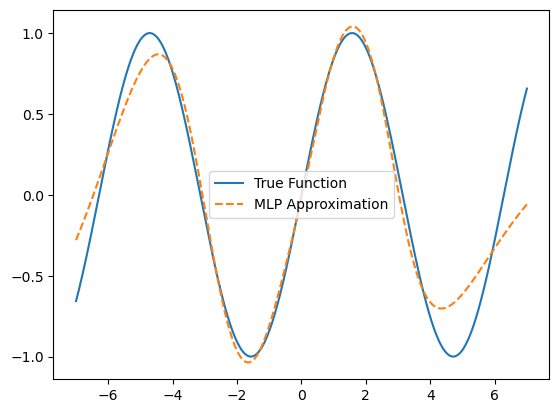

In [15]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

def create_mlp():
    """Crea una semplice MLP per approssimare una sinusoide."""
    model = nn.Sequential(
        nn.Linear(1, 8),
        nn.Sigmoid(),
        nn.Linear(8, 1)
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    return model, optimizer

def train_mlp(model, optimizer, epochs=5000):
    """Addestra la MLP per approssimare la funzione sin(x)."""
    x = torch.linspace(-7, 7, 800).unsqueeze(1)
    y = torch.sin(x)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        if (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.6f}")

def validate_mlp(model):
    """Valida la MLP e calcola l'accuratezza percentuale."""
    x_test = torch.linspace(-7, 7, 800).unsqueeze(1)
    y_test = torch.sin(x_test)
    y_pred = model(x_test).detach()
    mse = nn.MSELoss()(y_pred, y_test).item()
    accuracy = 100 * (1 - mse / torch.var(y_test).item())
    print(f"Validation Accuracy: {accuracy:.2f}%")

def plot_results(model):
    """Plotta i risultati della rete neurale."""
    x = torch.linspace(-7, 7, 800).unsqueeze(1)
    y_true = torch.sin(x)
    y_pred = model(x).detach()
    plt.plot(x.numpy(), y_true.numpy(), label="True Function")
    plt.plot(x.numpy(), y_pred.numpy(), label="MLP Approximation", linestyle="--")
    plt.legend()
    plt.show()

if __name__ == "__main__":
    model, optimizer = create_mlp()
    train_mlp(model, optimizer)
    validate_mlp(model)
    plot_results(model)
